(83739, 14)
(9616, 14)
(9616, 1)
(6949, 1)
                                                                                   tagline
0   Inspired by the actual files of Father Gabriele Amorth, Chief Exorcist of the Vatican.
18                                                 Witness the beginning of a new dynasty.
39                                   Finding that special someone can be a real adventure.
45                                                                           Oh. My. Gods.
61                                                                      Return to Pandora.


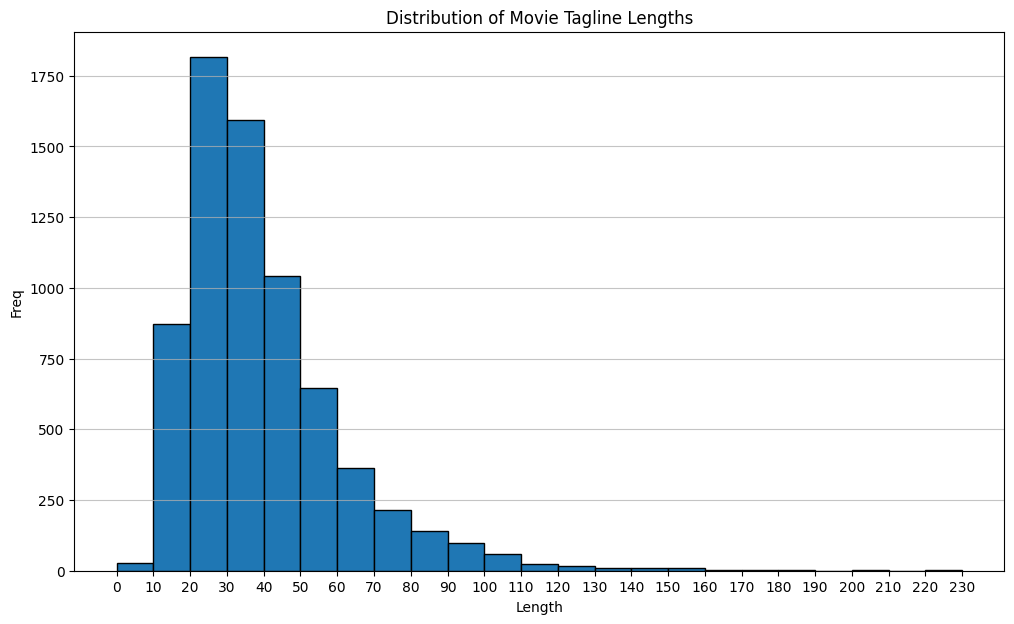

In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/9500plus-popular-movies-tmdb/9616 UNIQUE IMDB.csv')
print(df.shape)
df = df.drop_duplicates(subset=['title'], keep='first').copy()
print(df.shape)
df = df[['tagline']].copy()
print(df.shape)
df = df[df['tagline'] != 'No Tagline']
print(df.shape)
with pd.option_context('display.max_colwidth', None):
    print(df.head())

strlens = df['tagline'].str.len()
bins = [x for x in range(0, 231, 10)]

plt.figure(figsize=(12, 7))
plt.hist(strlens, bins=bins, edgecolor='black')
plt.title('Distribution of Movie Tagline Lengths')
plt.xlabel('Length')
plt.ylabel('Freq')
plt.xticks(bins) 
plt.grid(axis='y', alpha=0.75)
plt.show()

In [41]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, pipeline, DataCollatorForLanguageModeling
from datasets import Dataset

data = Dataset.from_pandas(df)
data = data.rename_column("tagline", "text")
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id
    
def tokenfunc(inputs):
    return tokenizer(inputs["text"], truncation=True, padding="max_length", max_length=235)

tokenized_data = data.map(tokenfunc, batched=True)
tokenized_data = tokenized_data.remove_columns(["text"])

trainargs = TrainingArguments(
    output_dir="./movie_tagline_generator",
    overwrite_output_dir=True,
    num_train_epochs=15, 
    per_device_train_batch_size=32,
    save_steps=1000,
    save_total_limit=2,
    prediction_loss_only=True,
    report_to="none", 
)

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

trainer = Trainer(
    model=model,
    args=trainargs,
    train_dataset=tokenized_data,
    data_collator=data_collator
)

trainer.train()
modelname = "./tuned_movie_tagline_generator"
trainer.save_model(modelname)

generator = pipeline('text-generation', model=modelname, tokenizer=tokenizer)


Map:   0%|          | 0/6949 [00:00<?, ? examples/s]

Step,Training Loss
500,3.536300
1000,2.946400
1500,2.611700
2000,2.357400
2500,2.177500
3000,2.071400


Device set to use cuda:0


In [42]:
import random

prompt = "A movie tagline:"

for i in range(50):
    rand = random.randint(5, 50)
    generated_text = generator(prompt, max_new_tokens=rand) 
    print(generated_text)

[{'generated_text': "A movie tagline: The funniest film of the decade.  The coolest ending.  The funniest ending.  The funniest ending.   This is all for a little love.  Not a movie that's about love. It"}]
[{'generated_text': "A movie tagline: 'Blanche, Ruthless, Deadlier' which should"}]
[{'generated_text': "A movie tagline: “If this weren't"}]
[{'generated_text': 'A movie tagline: "Nobody\'s listening" goes a long way.  Everybody is watching until a movie ends.  Everyone is'}]
[{'generated_text': 'A movie tagline: You may be crazy, but believe it or not. This comic ends with the meanie tale...'}]
[{'generated_text': "A movie tagline: 'Anything goes down without problem' - right before the storm! - and this is no movie"}]
[{'generated_text': "A movie tagline: 'Wherever you go, you get what you pay for'."}]
[{'generated_text': 'A movie tagline: Life goes on forever. In just 12 minutes. You'}]
[{'generated_text': 'A movie tagline: "Lonely men" would kill for love! The men in question w

In [ ]:
# So here I trained a model to produce movie taglines. Kaggle has a movies database that, after removing all columns but tagline and
# de-duping, has about 7000 taglines. I have separated the generation from the training, so a user should be able to generate
# new taglines without having to wait for a re-training. Overall, this model is not impressive. Very few of the taglines
# are coherent, realistic, and correctly punctuated. Most of them are close, but the model keeps generating up to the token limit,
# then just stops mid-thought. It can't tell that it needs to stop earlier. Example: "Love, loyalty, danger. The". This would be 
# fine if it weren't for the 'The' at the end. A close one: "Nobody in Hollywood is prepared to give you top gross". This is
# actually a coherent thought that we could absolutely see as a real movie tagline, but is was missing the period at the end
# and the closing quote mark. 

# training output: [3270/3270 38:13, Epoch 15/15] 
# Step 	Training Loss
# 500 	3.536300
# 1000 	2.946400
# 1500 	2.611700
# 2000 	2.357400
# 2500 	2.177500
# 3000 	2.071400